# Código base para cargar una imagen FITS / Starter code to load a FITS image

Este notebook solo sirve para **abrir y visualizar** la imagen FITS que se usará en la actividad.  
This notebook is only intended to **open and visualize** the FITS image used in the activity.

No incluye la deproyección, el mapa polar, el perfil radial ni la medición de brechas. Esos pasos corresponden al desarrollo de la actividad.  
It does not include the deprojection, polar map, radial profile, or gap measurement. Those steps are part of the activity itself.

## Instrucción / Instructions

1. Descarga una imagen FITS desde la página web del catálogo.  
   Download a FITS image from the catalog website.

2. Deja este notebook en la misma carpeta que el FITS, o ejecútalo desde la carpeta principal del repositorio.  
   Keep this notebook in the same folder as the FITS file, or run it from the main folder of the repository.

3. Elige el disco en la celda 2.  
   Choose the disk in cell 2.

4. Ejecuta las celdas en orden.  
   Run the cells in order.

## 1. Importar librerías / Import libraries

Si falta alguna librería, instala primero:  
If any library is missing, install it first:

```bash
pip install numpy matplotlib astropy
```

In [13]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.visualization import ImageNormalize, AsinhStretch, PercentileInterval

try:
    from matplotlib.patches import Ellipse
except ImportError:
    Ellipse = None

## 2. Elegir el disco y encontrar el archivo FITS / Select the disk and find the FITS file

Puedes elegir:  
You can choose:

- `"HD163296"`
- `"IMLup"`

El código intenta encontrar el FITS de dos maneras:  
The code tries to find the FITS file in two ways:

1. en la misma carpeta donde está este notebook;  
   in the same folder where this notebook is located;

2. dentro de las carpetas del repositorio del catálogo.  
   inside the catalog repository folders.

In [14]:
# Elige el disco aquí
DISK_NAME = "HD163296"  # opciones: "HD163296" o "IMLup"

# Nombres esperados de los archivos FITS
fits_names = {
    "HD163296": "HD163296_continuum.fits",
    "IMLup": "IMLup_continuum.fits",
}

# Rutas posibles dentro del repositorio del catálogo
repo_paths = {
    "HD163296": Path("data/actividades/actividad_hd163296/HD163296_continuum.fits"),
    "IMLup": Path("data/actividades/actividad_im_lup/IMLup_continuum.fits"),
}

def buscar_fits(disk_name):
    """Busca el archivo FITS en la carpeta actual o dentro del repositorio."""
    nombre_fits = fits_names[disk_name]

    rutas_posibles = [
        Path(nombre_fits),              # si el FITS está en la misma carpeta del notebook
        repo_paths[disk_name],          # si se ejecuta desde la raíz del repositorio
        Path.cwd() / nombre_fits,       # ruta absoluta desde la carpeta actual
        Path.cwd() / repo_paths[disk_name],
    ]

    for ruta in rutas_posibles:
        if ruta.exists():
            return ruta

    mensaje = (
        f"No se encontró el archivo FITS para {disk_name}.\n\n"
        "Revisa una de estas opciones:\n"
        f"1. deja el archivo '{nombre_fits}' en la misma carpeta que este notebook; o\n"
        f"2. ejecuta el notebook desde la carpeta principal del repositorio, donde exista '{repo_paths[disk_name]}'."
    )
    raise FileNotFoundError(mensaje)

fits_path = buscar_fits(DISK_NAME)

print(f"Disco seleccionado: {DISK_NAME}")
print(f"Archivo FITS encontrado en: {fits_path}")

Disco seleccionado: HD163296
Archivo FITS encontrado en: HD163296_continuum.fits


## 3. Abrir el archivo FITS / Open the FITS file

Esta celda abre el FITS, muestra la estructura del archivo y extrae la imagen principal.  
This cell opens the FITS file, displays the file structure, and extracts the main image.

In [15]:
with fits.open(fits_path) as hdul:
    hdul.info()
    header = hdul[0].header.copy()
    data = hdul[0].data

# Muchos FITS de ALMA tienen dimensiones extra de frecuencia/Stokes.
# np.squeeze elimina dimensiones de tamaño 1 y deja una imagen 2D.
image = np.squeeze(data).astype(float)

# Reemplazar valores no finitos por NaN
image[~np.isfinite(image)] = np.nan

if image.ndim != 2:
    raise ValueError(
        f"La imagen después de np.squeeze tiene {image.ndim} dimensiones. "
        "Este notebook espera una imagen 2D."
    )

print("Tamaño de la imagen:", image.shape)
print("Valor mínimo:", np.nanmin(image))
print("Valor máximo:", np.nanmax(image))
print("Unidad en el header:", header.get("BUNIT", "no especificada"))

Filename: HD163296_continuum.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      80   (3000, 3000, 1, 1)   float32   
Tamaño de la imagen: (3000, 3000)
Valor mínimo: -0.0001156213620561175
Valor máximo: 0.004264533054083586
Unidad en el header: Jy/beam


## 4. Preparar una versión centrada de la imagen / Prepare a centered version of the image

Esta celda recorta una región central para que el disco se vea mejor.  
This cell crops a central region so the disk can be seen more clearly.

Si quieres ver toda la imagen, cambia `CROP_SIZE = None`.  
If you want to see the full image, change `CROP_SIZE = None`.

In [16]:
# Tamaño del recorte en píxeles.
# Usa None para no recortar.
CROP_SIZE = 1000

ny, nx = image.shape

# Centro aproximado de la imagen.
# Si el header tiene CRPIX1/CRPIX2, se usa ese centro.
x_center = int(round(header.get("CRPIX1", nx / 2) - 1))
y_center = int(round(header.get("CRPIX2", ny / 2) - 1))

if CROP_SIZE is None:
    image_plot = image
    x0, x1 = 0, nx
    y0, y1 = 0, ny
else:
    half = CROP_SIZE // 2
    x0 = max(x_center - half, 0)
    x1 = min(x_center + half, nx)
    y0 = max(y_center - half, 0)
    y1 = min(y_center + half, ny)
    image_plot = image[y0:y1, x0:x1]

print("Centro usado (x, y):", x_center, y_center)
print("Tamaño de la imagen para graficar:", image_plot.shape)

Centro usado (x, y): 1500 1500
Tamaño de la imagen para graficar: (1000, 1000)


## 5. Graficar la imagen FITS / Plot the FITS image

La imagen se muestra en coordenadas de píxel.  
The image is shown in pixel coordinates.

Esto es suficiente para confirmar que el FITS se cargó correctamente.  
This is enough to confirm that the FITS file was loaded correctly.

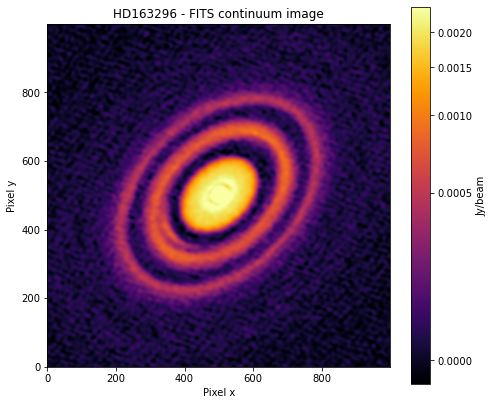

In [ ]:
# Escala robusta para visualizar mejor la emisión del disco
interval = PercentileInterval(99.5)
vmin, vmax = interval.get_limits(image_plot)
norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=AsinhStretch(0.1))

plt.figure(figsize=(7, 6))
plt.imshow(image_plot, origin="lower", cmap="inferno", norm=norm)
plt.colorbar(label=header.get("BUNIT", "Intensity"))
plt.title(f"{DISK_NAME} - FITS continuum image")
plt.xlabel("Pixel x")
plt.ylabel("Pixel y")
plt.tight_layout()
plt.show()

## 6. Graficar con offsets aproximados en arcsec / Plot with approximate arcsec offsets

Si el header tiene información de escala angular, esta celda grafica la imagen con offsets aproximados en arcsec respecto al centro.  
If the header contains angular scale information, this cell plots the image with approximate arcsec offsets relative to the center.

Esto ayuda a conectar la imagen con la interpretación astronómica, pero sigue siendo solo una visualización inicial.  
This helps connect the image with the astronomical interpretation, but it is still only an initial visualization.

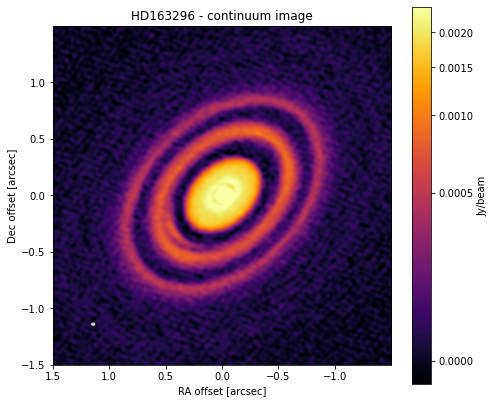

In [18]:
# Intentar construir ejes en arcsec usando CDELT1/CDELT2
if "CDELT1" in header and "CDELT2" in header:
    cdelt1 = header["CDELT1"] * 3600.0  # deg/pix -> arcsec/pix
    cdelt2 = header["CDELT2"] * 3600.0

    x_pixels = np.arange(x0, x1)
    y_pixels = np.arange(y0, y1)

    x_arcsec = (x_pixels - x_center) * cdelt1
    y_arcsec = (y_pixels - y_center) * cdelt2

    extent = [x_arcsec[0], x_arcsec[-1], y_arcsec[0], y_arcsec[-1]]

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(
        image_plot,
        origin="lower",
        cmap="inferno",
        norm=norm,
        extent=extent,
        aspect="equal",
    )

    cb = plt.colorbar(im, ax=ax)
    cb.set_label(header.get("BUNIT", "Intensity"))

    ax.set_title(f"{DISK_NAME} - continuum image")
    ax.set_xlabel("RA offset [arcsec]")
    ax.set_ylabel("Dec offset [arcsec]")

    # Mostrar el beam si el header contiene la información necesaria
    if Ellipse is not None and all(key in header for key in ["BMAJ", "BMIN", "BPA"]):
        beam_maj = header["BMAJ"] * 3600.0
        beam_min = header["BMIN"] * 3600.0
        beam_pa = header["BPA"]

        x_beam = extent[0] + 0.12 * (extent[1] - extent[0])
        y_beam = extent[2] + 0.12 * (extent[3] - extent[2])

        beam = Ellipse(
            (x_beam, y_beam),
            width=beam_min,
            height=beam_maj,
            angle=beam_pa,
            facecolor="white",
            edgecolor="black",
            alpha=0.8,
        )
        ax.add_patch(beam)

    plt.tight_layout()
    plt.show()

else:
    print("El header no contiene CDELT1/CDELT2. Se mantiene la visualización en píxeles.")

## 7. Inicio de la actividad / Start of the activity

Si la imagen se cargó correctamente, ahora puedes comenzar el análisis morfológico:  
If the image was loaded correctly, you can now begin the morphological analysis:

1. aplicar la geometría del disco;  
   apply the disk geometry;

2. deproyectar la imagen;  
   deproject the image;

3. transformar la imagen a coordenadas polares;  
   transform the image into polar coordinates;

4. construir el perfil radial;  
   build the radial profile;

5. identificar anillos, brechas o depresiones radiales.  
   identify rings, gaps, or radial depressions.